In [42]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# Import directly from 'keras' instead of 'tensorflow.keras'
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.regularizers import l2
from keras.initializers import HeNormal
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [43]:
df = pd.read_csv('/Users/w3117643/pandas/projects/neuralNetworks_deepLearning/insurance_dataset.csv')

This project is about building and training a neural network as part of Deep Learning pracices, using Keras to predict individual medical insurance costs based on personal characterstics. The data comprises of five features including categorical and numerical data. Prior to training the neural network, data encoding and normalization is conducted for categorical variables and continuous variables, respectively. The target variable (charges: individual medical costs) is also normalized prior to training, validation and testing process. 

In [44]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [45]:
df['charges'].describe() # distribution of the target variable

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

In [46]:
# checking missign values
print(df.isna().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [47]:
# checking missign values
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [48]:
print(df.dtypes)

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


In [49]:
# cols I want to encode to numbers - handling categorical variables
categorical_cols = ['sex', 'smoker', 'region']

In [50]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True,dtype=int)

In [51]:
features = df_encoded.drop('charges', axis=1)
features

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,0,1,0,0,1
1,18,33.770,1,1,0,0,1,0
2,28,33.000,3,1,0,0,1,0
3,33,22.705,0,1,0,1,0,0
4,32,28.880,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,1,0,1,0,0
1334,18,31.920,0,0,0,0,0,0
1335,18,36.850,0,0,0,0,1,0
1336,21,25.800,0,0,0,0,0,1


In [52]:
target = df_encoded['charges']
target

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [53]:
 # split the dataset into three: training, validation and test sets
x_temp, x_test, y_temp, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size=0.25, random_state=42)

In [54]:
# normalize numerical columns
numerical_cols = ['age', 'children', 'bmi']
scaler = StandardScaler()

In [55]:
# Fit and transform the numerical columns
x_train[numerical_cols] = scaler.fit_transform(x_train[numerical_cols])
x_val[numerical_cols] = scaler.transform(x_val[numerical_cols]) # here i don't use fit_transform, but only .transform
x_test[numerical_cols]= scaler.transform(x_test[numerical_cols]) # same as above for test set, to avoid data lickage


In [56]:
x_train[numerical_cols]

,age,children,bmi
40,-1.074861,-0.903963,-0.638575
994,-0.861468,1.520714,-1.706102
165,0.561156,2.328940,-0.375561
1057,0.418894,-0.903963,0.206653
418,1.770386,-0.095737,1.406908
...,...,...,...
953,0.347762,0.712488,-0.052290
450,-0.007894,2.328940,-0.150004
83,0.632287,2.328940,1.744022
747,-1.430517,-0.903963,-1.427616


In [57]:
x_train

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
40,-1.074861,-0.638575,-0.903963,0,0,0,0,0
994,-0.861468,-1.706102,1.520714,0,1,1,0,0
165,0.561156,-0.375561,2.328940,1,0,0,0,0
1057,0.418894,0.206653,-0.903963,0,0,0,1,0
418,1.770386,1.406908,-0.095737,1,0,0,1,0
...,...,...,...,...,...,...,...,...
953,0.347762,-0.052290,0.712488,1,1,0,0,1
450,-0.007894,-0.150004,2.328940,1,0,0,0,1
83,0.632287,1.744022,2.328940,0,0,1,0,0
747,-1.430517,-1.427616,-0.903963,1,0,1,0,0


In [58]:
y_train

40       3046.06200
994     16420.49455
165     10407.08585
1057    17929.30337
418     14418.28040
           ...     
953     38998.54600
450      7512.26700
83      11033.66170
747      1627.28245
880      3443.06400
Name: charges, Length: 802, dtype: float64

In [59]:
# Reshape continuous target (y) to 2D for scikit-learn
y_train_2d = y_train.values.reshape(-1, 1)
y_val_2d = y_val.values.reshape(-1, 1)
y_test_2d = y_test.values.reshape(-1, 1)

# Normalize continuous targets strictly between 0 and 1
target_scaler = MinMaxScaler(feature_range=(0, 1))
y_train_scaled = target_scaler.fit_transform(y_train_2d)
y_val_scaled = target_scaler.transform(y_val_2d)
y_test_scaled = target_scaler.transform(y_test_2d)

In [60]:
len(y_train_scaled)

802

In [61]:
len(y_val_scaled)

268

In [62]:
# I chose to dynamically extract the correct number of columns
n_features = x_train.shape[1]
n_features

8

In [63]:
x_train

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
40,-1.074861,-0.638575,-0.903963,0,0,0,0,0
994,-0.861468,-1.706102,1.520714,0,1,1,0,0
165,0.561156,-0.375561,2.328940,1,0,0,0,0
1057,0.418894,0.206653,-0.903963,0,0,0,1,0
418,1.770386,1.406908,-0.095737,1,0,0,1,0
...,...,...,...,...,...,...,...,...
953,0.347762,-0.052290,0.712488,1,1,0,0,1
450,-0.007894,-0.150004,2.328940,1,0,0,0,1
83,0.632287,1.744022,2.328940,0,0,1,0,0
747,-1.430517,-1.427616,-0.903963,1,0,1,0,0


In [64]:
# Build model
model = Sequential([
    Dense(512, activation='relu', kernel_initializer=HeNormal(), kernel_regularizer=l2(0.001), input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid') # sicne the target variable is transformed I can use sigmoid instead of linear activation
])


/Users/w3117643/pandas/Projects/neuralNetworks_deepLearning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [65]:
model.compile(
    optimizer='adam',
    loss='mse', # mean squared error
    metrics=['mae'] # mean absolute error
)

In [66]:
# Set up callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15, # training will continue for 15 more epochs after val_loss stopped improving
        restore_best_weights=True, # after training is stopped the best weights will be saved
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model.keras', # model reflecting best weights will be saved automatically
        monitor='val_loss',
        save_best_only=True, # no other mdoels will be saved except the best model
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5, # learning rate will reduced by a factor mentioned here
        patience=5,
        min_lr=0.00001,
        verbose=1
    )
]

In [75]:
# Train with callbacks
history = model.fit(
    x_train, y_train_scaled,
    validation_data=(x_val, y_val_scaled), # evaluation on validation set
    epochs=500,
    batch_size=256, # the size of dataset processed at a time within each epoch during training the model
    callbacks=callbacks
)

Epoch 1/500
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0193 - mae: 0.0448
Epoch 1: val_loss improved from 0.02414 to 0.02413, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0200 - mae: 0.0480 - val_loss: 0.0241 - val_mae: 0.0573 - learning_rate: 3.1250e-05
Epoch 2/500
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0201 - mae: 0.0543
Epoch 2: val_loss did not improve from 0.02413
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0202 - mae: 0.0495 - val_loss: 0.0242 - val_mae: 0.0578 - learning_rate: 3.1250e-05
Epoch 3/500
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0198 - mae: 0.0511
Epoch 3: val_loss did not improve from 0.02413
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0195 - mae: 0.0490 - val_loss: 0.0243 - val_mae: 0.0582 - learning_rate: 3.1250e-05
Epoch 4/500
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0185 - mae: 0.0428
Epoch 4: val_loss did not improve from 0.02413
4/4 ━━━━━━

In [68]:
# Extract loss logs from the history dictionary
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(train_loss) + 1)


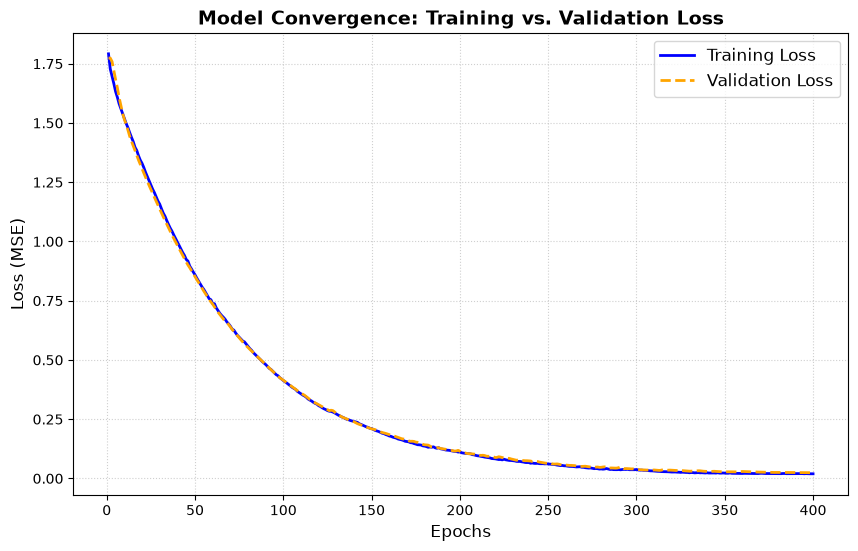

In [69]:
# plot
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, train_loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2, linestyle='--')

# Add titles and visual anchors
plt.title('Model Convergence: Training vs. Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# Display the chart
plt.show()

In [70]:
# Check training loss in evaluation mode (turns off Batch Normalization noise)
true_train_loss, _ = model.evaluate(x_train, y_train_scaled, verbose=0)
true_val_loss, _ = model.evaluate(x_val, y_val_scaled, verbose=0)

print(f"True Baseline Training Loss: {true_train_loss:.4f}")
print(f"True Baseline Validation Loss: {true_val_loss:.4f}")


True Baseline Training Loss: 0.0184
True Baseline Validation Loss: 0.0241


In [71]:
# Saving my model on my disk
model.save('best_insurance_model.keras')
print("Model saved successfully as 'best_insurance_model.keras'!")

Model saved successfully as 'best_insurance_model.keras'!


In [72]:
# Check training loss in evaluation mode (turns off Batch Normalization noise)
true_train_loss, _ = model.evaluate(x_train, y_train_scaled, verbose=0)
true_val_loss, _ = model.evaluate(x_val, y_val_scaled, verbose=0)

print(f"True Baseline Training Loss: {true_train_loss:.4f}")
print(f"True Baseline Validation Loss: {true_val_loss:.4f}")

True Baseline Training Loss: 0.0184
True Baseline Validation Loss: 0.0241


In [80]:
# Calculating performance metrics on my hidden test dataset
test_loss, test_mae = model.evaluate(x_test, y_test_scaled, verbose=0)

print(f" Final Evaluation Metrics on Test Set:")
print(f"-> My model's test loss (MSE):          {test_loss:.4f}")
print(f"-> the Mean Absolute Error (MAE): {test_mae:.4f}")

 Final Evaluation Metrics on Test Set:
-> My model's test loss (MSE):          0.0198
-> the Mean Absolute Error (MAE): 0.0436


# To evaluate all three data splits to extract both metrics, the following can be used.
train_mse, train_mae = model.evaluate(x_train, y_train_scaled, verbose=0)
val_mse, val_mae     = model.evaluate(x_val, y_val_scaled, verbose=0)
test_mse, test_mae   = model.evaluate(x_test, y_test_scaled, verbose=0)

In [ ]:
# Generating predictions
test_predictions_norm = model.predict(x_test, verbose=0)

In [ ]:
len(test_predictions_norm)

268

In [79]:
# Convert them back to original dollar amounts
test_predictions_dollars = target_scaler.inverse_transform(test_predictions_norm)
actual_dollars = target_scaler.inverse_transform(y_test_scaled)

In [ ]:
# Viewing a few side-by-side for my comparison
print("--- Test Set Predictions ---")
for i in range(5):
    print(f"Predicted: ${test_predictions_dollars[i][0]:,.2f} | Actual: ${actual_dollars[i][0]:,.2f}")


--- Test Set Predictions ---
Predicted: $9,955.11 | Actual: $9,095.07
Predicted: $4,614.64 | Actual: $5,272.18
Predicted: $26,522.73 | Actual: $29,330.98
Predicted: $8,251.82 | Actual: $9,301.89
Predicted: $30,513.59 | Actual: $33,750.29


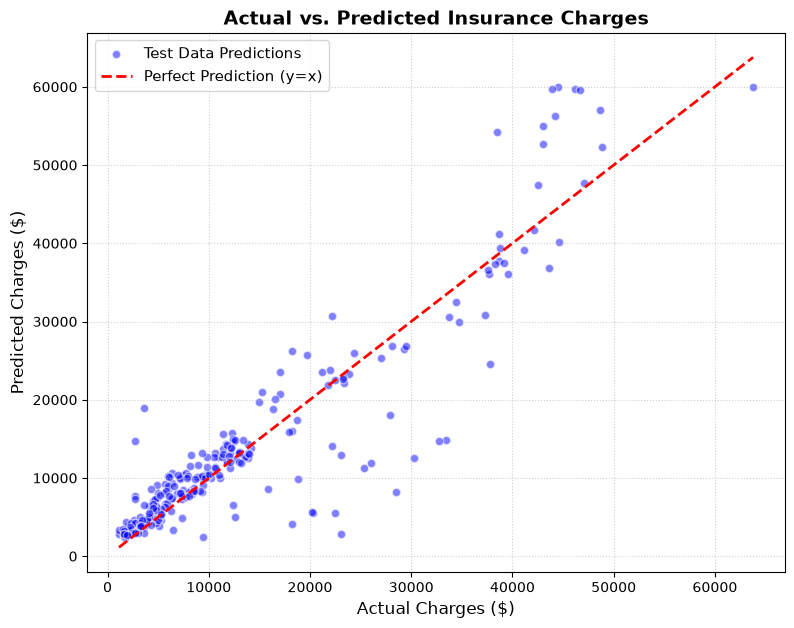

In [ ]:
# scatter plot comparing predicted charges to actual charges.
from matplotlib import pyplot as plt
plt.figure(figsize=(9, 7))
plt.scatter(actual_dollars, test_predictions_dollars, color='blue', alpha=0.5, edgecolors='w', label='Test Data Predictions')

# Adding the ideal 45-degree diagonal reference line (y = x)
max_val = max(max(actual_dollars), max(test_predictions_dollars))
min_val = min(min(actual_dollars), min(test_predictions_dollars))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

# Adding titles and labels
plt.title('Actual vs. Predicted Insurance Charges', fontsize=14, fontweight='bold')
plt.xlabel('Actual Charges ($)', fontsize=12)
plt.ylabel('Predicted Charges ($)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# Display the chart
plt.show()


Summary: The model is working greate as the training loss is the lowest and validation loss is slightly higher but it stopped improving at 0.0365. The model did great on a new test dataset with loss of 0.0326 even better than the validation loss, which I think is great. So it fits well, it is NOT under or overfitting. So the model learned the pattern well and predicts fairly accurately on new datset with MAE 0.0493. Low MAE means the model can predict values close to the actual target value. The above figure also shows the distribution of predicted values follows closely to the expected actual values. In my opinion, the model is doing great. The predicted values are slightly above or under the actual dollars. 